# Storico allenatori

Versione interattiva di `scripts/generate_coaches_history.py`. Per ogni coach stampa il riepilogo e visualizza il grafico nel notebook, senza salvare CSV o PNG.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_results
from src.statistics import count_results

## Funzioni di supporto

In [2]:
def build_summary(coach: str, coach_results: pd.Series) -> pd.DataFrame:
    base_counts = count_results(coach_results)
    counts = {
        "Partecipazioni": base_counts["Partecipazioni"],
        "Vittorie": base_counts["Vittorie"],
        "Primi 3": base_counts["Primi 3"],
        "Risultati neutri": int((coach_results == "N").sum()),
        "Retrocessioni": base_counts["Retrocessioni"],
    }
    participations = counts["Partecipazioni"]
    percentages = {
        column: f"{(value / participations * 100 if participations else 0.0):.2f}%"
        for column, value in counts.items()
        if column != "Partecipazioni"
    }
    percentages["Partecipazioni"] = ""
    return pd.DataFrame(
        [
            {"Tipo": "Conteggi", "Nome": coach, **counts},
            {
                "Tipo": "Percentuali",
                "Nome": "",
                **{column: percentages[column] for column in counts},
            },
        ]
    )


def show_chart(coach: str, coach_results: pd.Series, conversion: dict[str, float]) -> None:
    seasons = [f"{year}/{str(year + 1)[-2:]}" for year in coach_results.index]
    values = [np.nan if result == "A" else conversion[result] for result in coach_results]
    x_positions = np.arange(len(seasons))

    figure, axis = plt.subplots(figsize=(9, 5))
    axis.plot(x_positions, values, marker="o", linewidth=2)
    axis.set_title(f"Risultati per stagione - {coach}")
    axis.set_xlabel("Stagione")
    axis.set_ylabel("Valore del risultato")
    axis.set_xticks(x_positions, seasons)
    axis.set_yticks(sorted(set(conversion.values())))
    axis.grid(True, alpha=0.3)
    figure.tight_layout()
    plt.show()
    plt.close(figure)

## Configurazione e dati

In [3]:
with (PROJECT_ROOT / "configs" / "config.yaml").open(encoding="utf-8") as stream:
    config = yaml.safe_load(stream)

years = config["year_selection"]
conversion = config["result_to_number_conversion"]
results = load_results(
    PROJECT_ROOT / config["data"]["file_path"],
    years["first_year"],
    years["last_year"],
)

print(f"Stagioni caricate: {years['first_year']}/{str(years['first_year'] + 1)[-2:]} - {years['last_year']}/{str(years['last_year'] + 1)[-2:]}")
print(f"Allenatori: {len(results.columns)}")

Stagioni caricate: 2020/21 - 2025/26
Allenatori: 14


## Riepiloghi e grafici

Per ispezionare un solo coach, sostituisci `results.columns` con una lista come `["Nome coach"]`.


Lippo
       Tipo  Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Lippo              6        1       2                2             1
Percentuali                        16.67%  33.33%           33.33%        16.67%


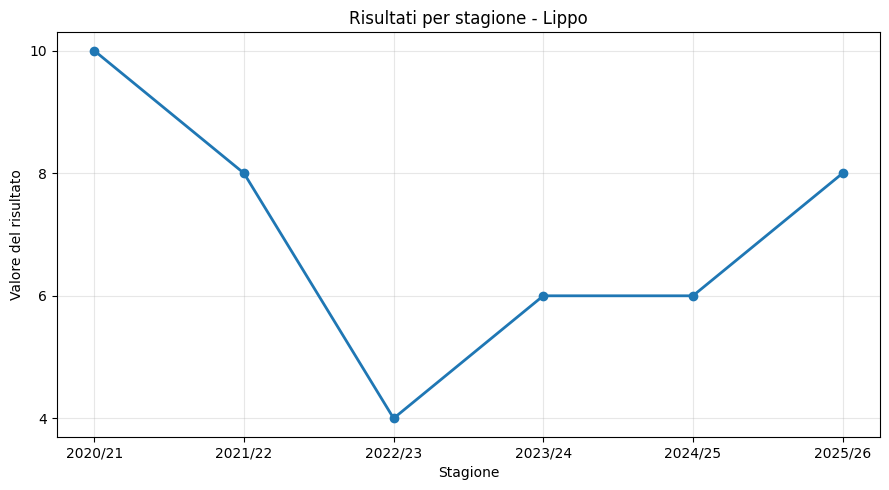


Gallo
       Tipo  Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Gallo              6        1       2                0             3
Percentuali                        16.67%  33.33%            0.00%        50.00%


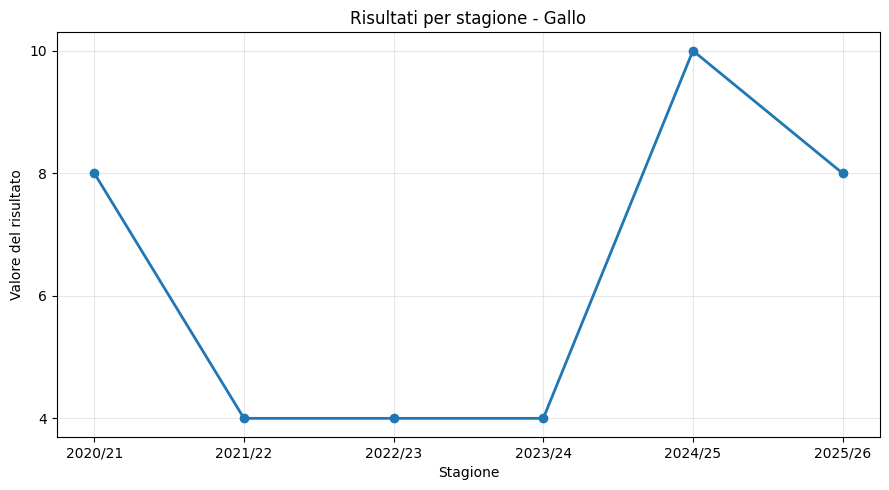


Cappo
       Tipo  Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Cappo              6        1       1                2             2
Percentuali                        16.67%  16.67%           33.33%        33.33%


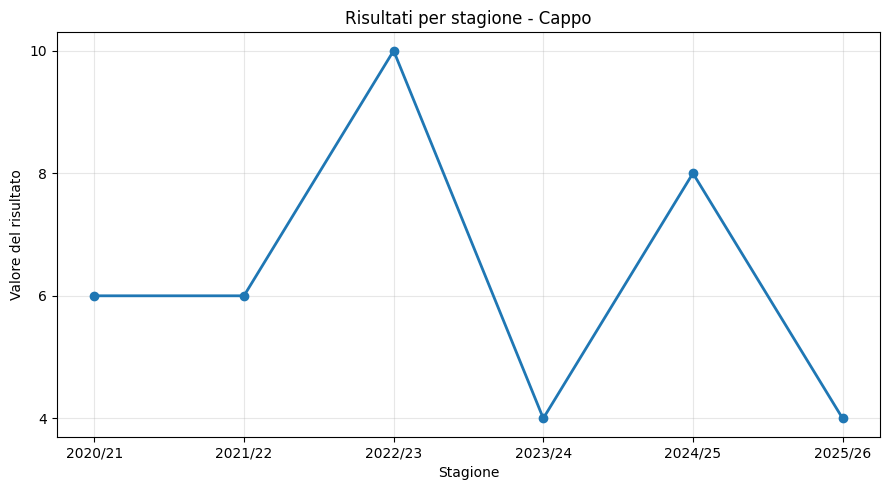


Cucu
       Tipo Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Cucu              6        0       3                3             0
Percentuali                        0.00%  50.00%           50.00%         0.00%


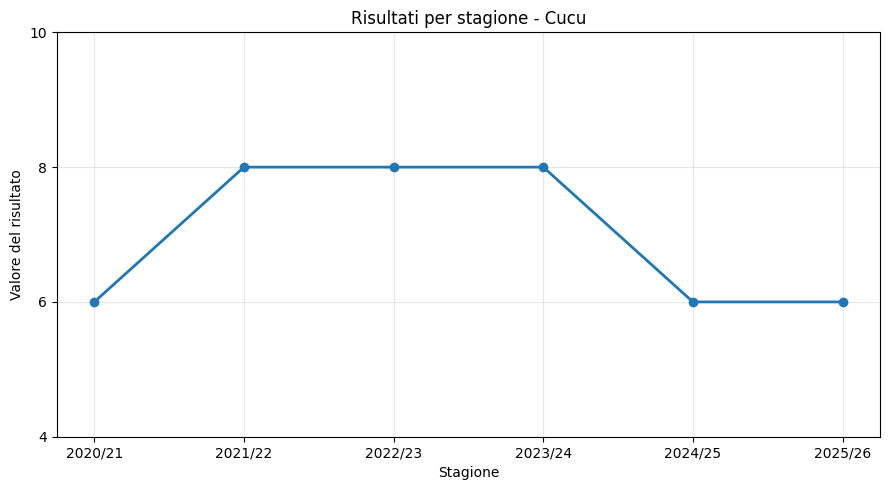


Manu
       Tipo Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Manu              6        1       2                2             1
Percentuali                       16.67%  33.33%           33.33%        16.67%


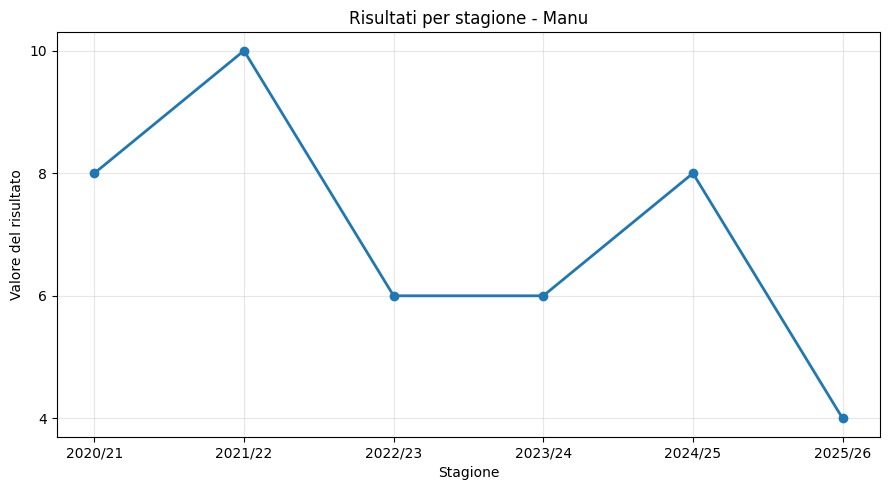


Mett
       Tipo Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Mett              2        0       0                0             2
Percentuali                        0.00%   0.00%            0.00%       100.00%


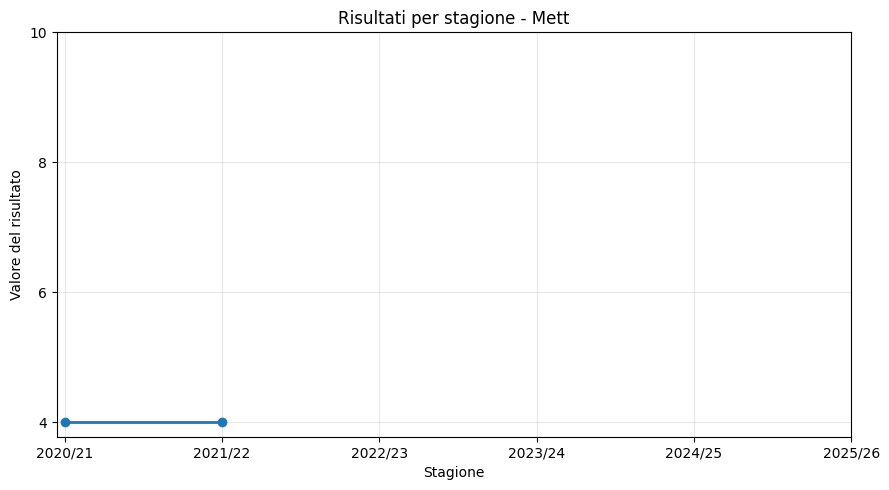


Fabio
       Tipo  Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Fabio              5        0       0                2             3
Percentuali                         0.00%   0.00%           40.00%        60.00%


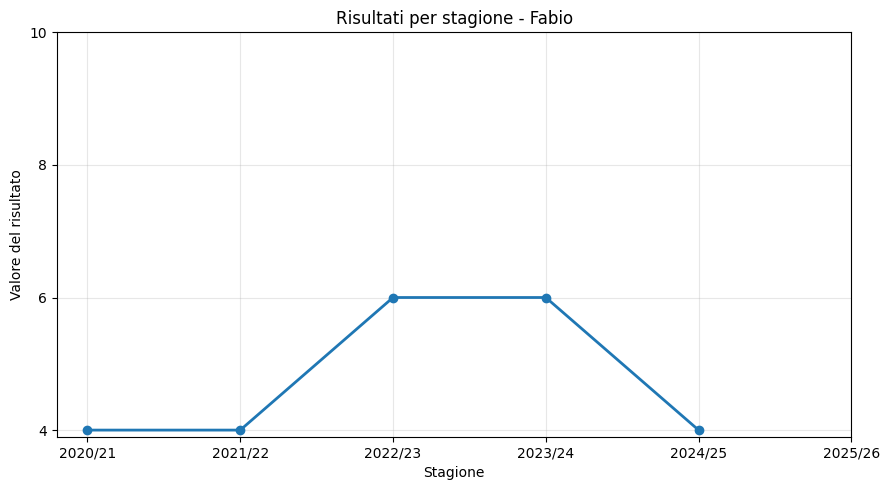


Zanu
       Tipo Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Zanu              6        1       0                4             1
Percentuali                       16.67%   0.00%           66.67%        16.67%


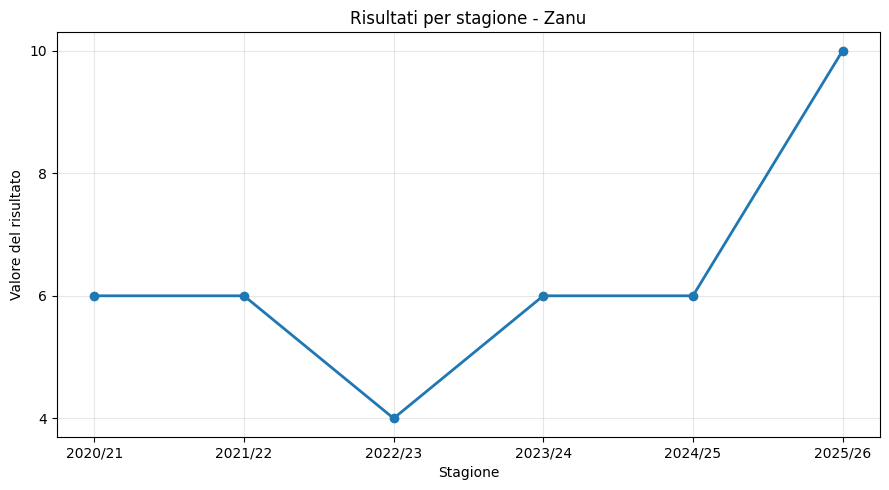


Pippi
       Tipo  Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Pippi              6        1       1                1             3
Percentuali                        16.67%  16.67%           16.67%        50.00%


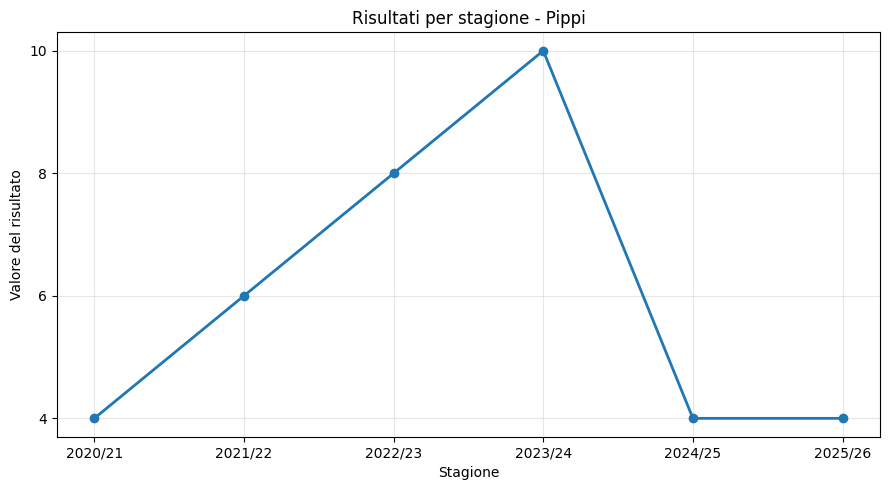


Furlan
       Tipo   Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Furlan              3        0       0                3             0
Percentuali                          0.00%   0.00%          100.00%         0.00%


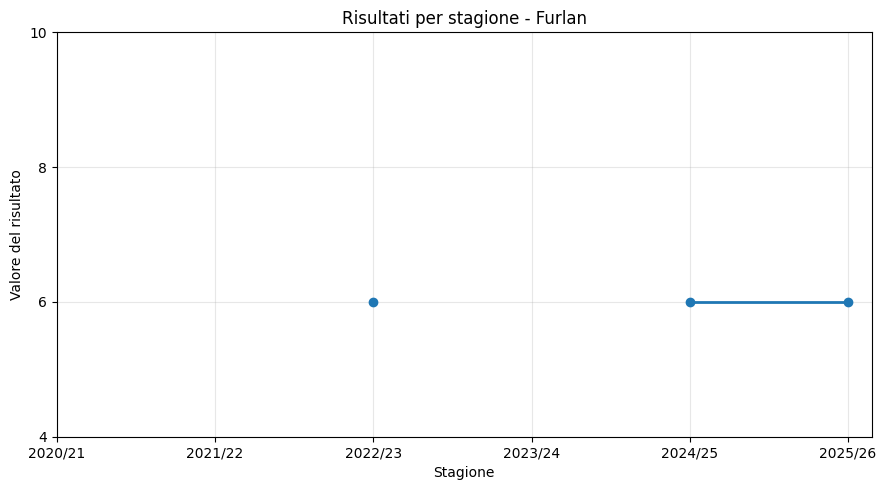


Alex
       Tipo Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Alex              1        0       0                1             0
Percentuali                        0.00%   0.00%          100.00%         0.00%


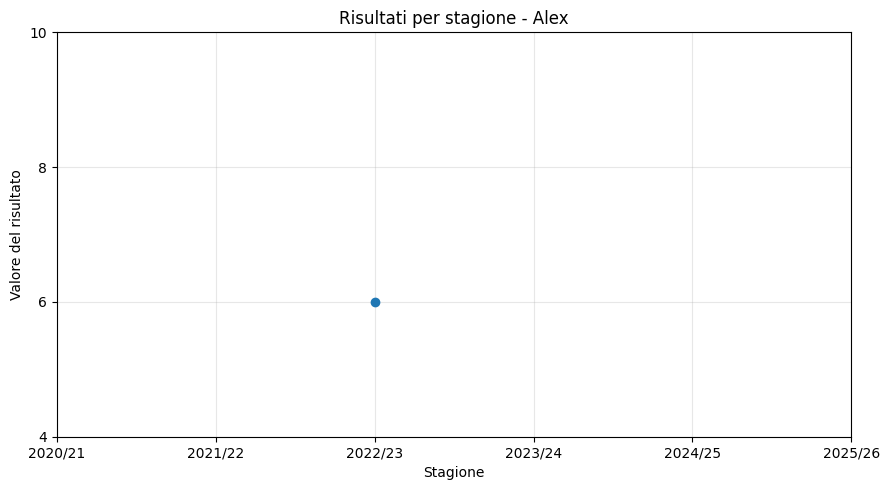


Jackino
       Tipo    Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Jackino              1        0       0                0             1
Percentuali                           0.00%   0.00%            0.00%       100.00%


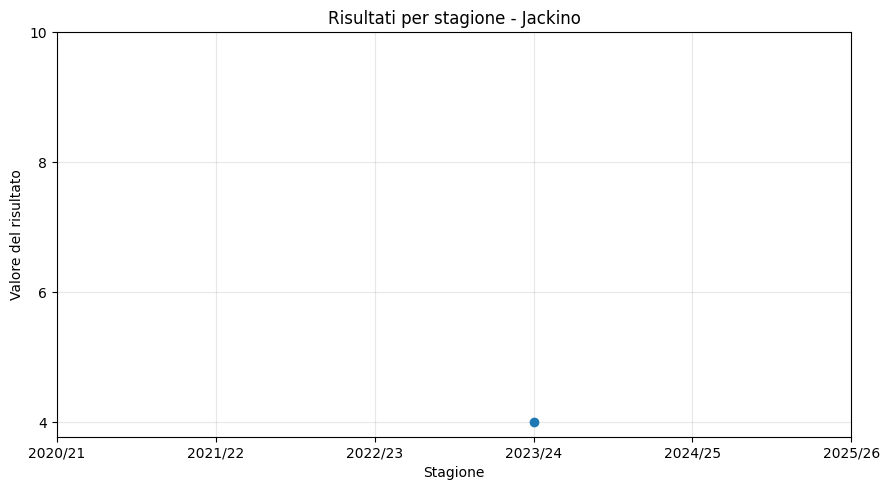


Javier
       Tipo   Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Javier              1        0       1                0             0
Percentuali                          0.00% 100.00%            0.00%         0.00%


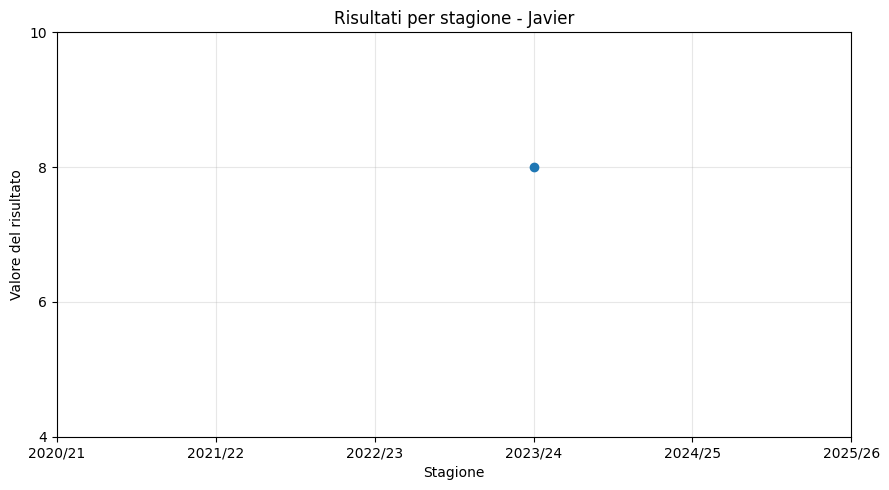


Luca
       Tipo Nome Partecipazioni Vittorie Primi 3 Risultati neutri Retrocessioni
   Conteggi Luca              1        0       0                0             1
Percentuali                        0.00%   0.00%            0.00%       100.00%


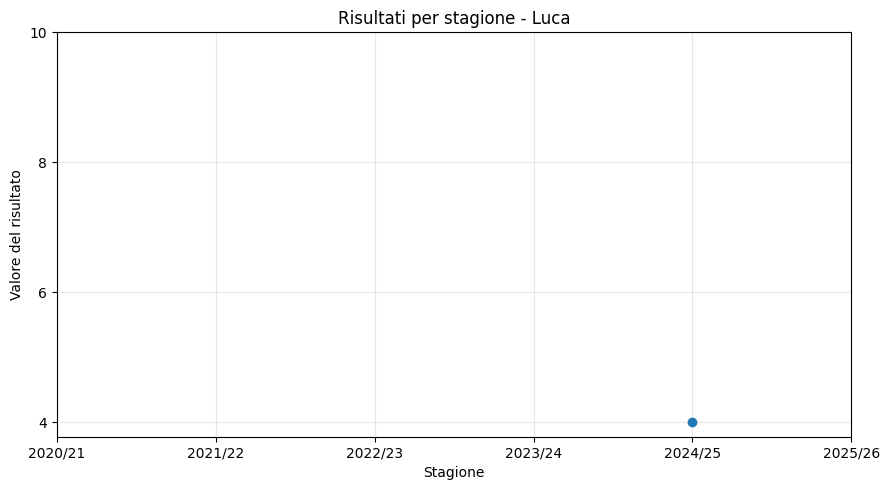

In [4]:
for coach in results.columns:
    print(f"\n{'=' * 80}\n{coach}\n{'=' * 80}")
    summary = build_summary(coach, results[coach])
    print(summary.to_string(index=False))
    show_chart(coach, results[coach], conversion)